# RQ4: Feature Importance Analysis

**Research Question:** Which clinical features are most predictive of patient mortality?

A Random Forest trained on the full preprocessing pipeline and extract feature importances. The `patient_id` column is dropped (non-informative identifier).

Model trained.

Top 10 Features:

         Feature  Importance
     cholesterol    0.133583
             bmi    0.129997
             age    0.128837
         glucose    0.124774
      creatinine    0.119119
     systolic_bp    0.113552
    diastolic_bp    0.110796
diagnosis_Sepsis    0.024818
    hypertension    0.018957
        diabetes    0.015278


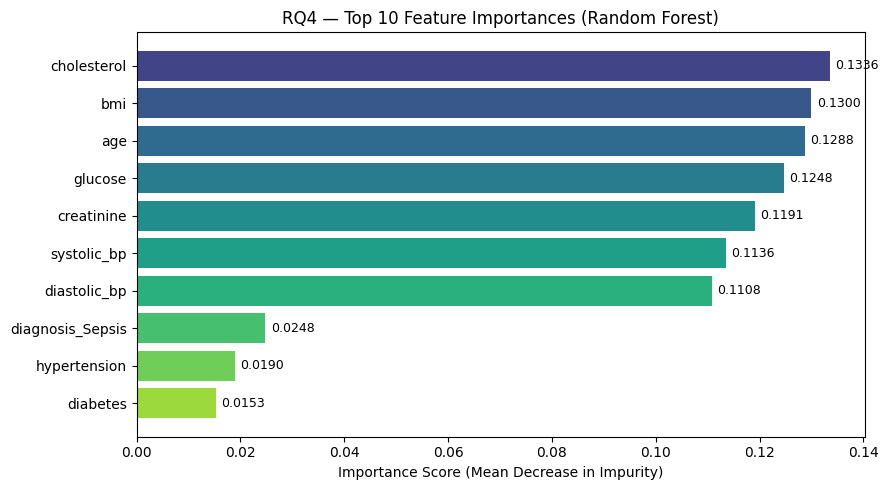

In [6]:
#IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

#LOAD
df = pd.read_csv('/kaggle/input/datasets/uom190346a/synthetic-clinical-tabular-dataset/synthetic_clinical_dataset.csv')

# Drop non-feature identifier column
if 'patient_id' in df.columns:
    df = df.drop(columns=['patient_id'])

y = df['mortality']
X = df.drop(columns=['mortality'])

numeric_cols     = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
#PIPELINE
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler',  StandardScaler())
    ]), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_cols)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        class_weight='balanced', random_state=42, n_estimators=200
    ))
])

model.fit(X_train, y_train)
print("Model trained.")
#FEATURE IMPORTANCE
num_feature_names = numeric_cols
cat_feature_names = (model.named_steps['preprocessor']
                     .named_transformers_['cat']
                     .named_steps['encoder']
                     .get_feature_names_out(categorical_cols))

all_feature_names = np.concatenate([num_feature_names, cat_feature_names])
importances = model.named_steps['model'].feature_importances_

feat_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

top10 = feat_df.head(10)
print("\nTop 10 Features:\n")
print(top10.to_string(index=False))
top10.to_csv('rq4_top_features.csv', index=False)
#PLOT
fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(top10)))
bars = ax.barh(top10['Feature'], top10['Importance'], color=colors)
ax.invert_yaxis()
ax.set_xlabel('Importance Score (Mean Decrease in Impurity)')
ax.set_title('RQ4 — Top 10 Feature Importances (Random Forest)')
for bar, val in zip(bars, top10['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('rq4_feature_importance.pdf')
plt.show()
